# Gridiron Brief MVP
## AI-Powered Fantasy Football League Chat Summarization

**Project Stage:** Minimum Viable Project (MVP)  
**Project Type:** Large Language Model / Dialogue Summarization  
**Dataset:** SAMSum  
**Planned Model:** Pre-trained BERT encoder-decoder architecture

### Bottom Line Up Front

Gridiron Brief is a proof-of-concept dialogue summarization system designed to reduce information overload in fantasy football league group chats. Using the SAMSum dataset, this project will fine-tune a pre-trained BERT encoder-decoder architecture to generate concise summaries of multi-speaker conversations.

The model will ultimately be evaluated with ROUGE-1, ROUGE-2, and ROUGE-L together with qualitative error analysis. A final domain-transfer demonstration will apply the trained model to fantasy-football-style conversations involving trades, injuries, waivers, league votes, and commissioner announcements.


# 1. Business Understanding

## Business Problem

Fantasy football leagues can generate dozens or hundreds of group-chat messages involving trades, waiver claims, player injuries, lineup decisions, league rules, and matchup results. Important information may become buried among jokes, reactions, and unrelated discussion.

**Gridiron Brief** is intended to reduce this catch-up burden by transforming a lengthy multi-speaker conversation into a concise natural-language summary of the major topics, actions, and decisions.

## Stakeholder

The primary stakeholder is the product team for a messaging or fantasy-sports platform seeking to improve the experience of users returning to active league conversations.

## Business Objective

Reduce the time and cognitive effort required to catch up on active group chats while preserving the information most relevant to league participation.

## Machine-Learning Objective

Fine-tune a pre-trained BERT encoder-decoder model on SAMSum so that it can generate concise abstractive summaries of unseen dialogue.

## Evaluation Plan

The primary quantitative metrics will be **ROUGE-1, ROUGE-2, and ROUGE-L**. Quantitative evaluation will be supplemented with qualitative review for factual accuracy, speaker attribution, omissions, repetition, hallucination, fluency, and conciseness.

## Initial Success Targets

| Measure | Target |
|---|---:|
| ROUGE-1 | ≥ 35 |
| ROUGE-2 | ≥ 12 |
| ROUGE-L | ≥ 32 |
| Human usefulness rating | ≥ 4.0 / 5 |
| Major factual-error-free summaries | ≥ 85% |

## Scope

The project focuses on dialogue summarization. Player projections, trade recommendations, live injury feeds, and predictive sports analytics are outside the MVP scope.

### Central Research Question

> **Can a pre-trained BERT encoder-decoder model convert a lengthy group conversation into a concise, useful summary?**


# 2. Data Understanding

The SAMSum corpus contains messenger-style conversations paired with human-written summaries. The dataset provides predefined training, validation, and test splits, which will be retained for the project.

This section will verify the dataset structure, inspect data quality, characterize dialogue and summary lengths, and examine the conversational structure before tokenization.


In [1]:
# Optional: run only if these packages are missing from the current environment.
# %pip install -q datasets transformers accelerate evaluate rouge_score

import sys
import platform
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import AutoTokenizer

from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.10.20
Platform: Windows-10-10.0.26200-SP0
PyTorch: 2.14.0+cpu
CUDA available: False


In [2]:
# Load the official SAMSum dataset from Hugging Face.
# The existing train/validation/test splits will be preserved.

dataset = load_dataset("knkarthick/samsum")

dataset


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [3]:
# Verify split sizes, columns, and schema.

split_overview = []

for split_name, split_data in dataset.items():
    split_overview.append({
        "split": split_name,
        "rows": len(split_data),
        "columns": ", ".join(split_data.column_names)
    })

split_overview_df = pd.DataFrame(split_overview)
display(split_overview_df)

print("\nDataset features:")
print(dataset["train"].features)


,split,rows,columns
0,train,14731,"id, dialogue, summary"
1,validation,818,"id, dialogue, summary"
2,test,819,"id, dialogue, summary"



Dataset features:
{'id': Value('string'), 'dialogue': Value('string'), 'summary': Value('string')}


In [4]:
# Inspect representative examples from the training set.

for i in range(3):
    example = dataset["train"][i]
    print(f"EXAMPLE {i + 1}")
    print("-" * 80)
    print("DIALOGUE:")
    print(example["dialogue"])
    print("\nHUMAN SUMMARY:")
    print(example["summary"])
    print("=" * 80, "\n")


EXAMPLE 1
--------------------------------------------------------------------------------
DIALOGUE:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

HUMAN SUMMARY:
Amanda baked cookies and will bring Jerry some tomorrow.

EXAMPLE 2
--------------------------------------------------------------------------------
DIALOGUE:
Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Olivia: Me too!!
Oliver: Great

HUMAN SUMMARY:
Olivia and Olivier are voting for liberals in this election. 

EXAMPLE 3
--------------------------------------------------------------------------------
DIALOGUE:
Tim: Hi, what's up?
Kim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating
Tim: What did you plan on doing?
Kim: Oh you know, uni stuff and unfucking my room
Kim: Maybe tomorrow I'll move my ass and do everything
Kim: We were going to defrost a fridge so instead of shopping I'll eat some defrosted veggies
Tim: For d

In [5]:
# Build a dataframe from the ORIGINAL dataset for the initial data-quality audit.

raw_frames = []

for split_name, split_data in dataset.items():
    frame = split_data.to_pandas()
    frame["split"] = split_name
    raw_frames.append(frame)

raw_eda_df = pd.concat(raw_frames, ignore_index=True)

print("Original dataset shape:", raw_eda_df.shape)


Original dataset shape: (16368, 4)


In [ ]:
# Data-quality audit: missing values, empty strings, and exact duplicates.

quality_rows = []

for split_name in dataset.keys():
    df_split = raw_eda_df.loc[raw_eda_df["split"] == split_name].copy()

    quality_rows.append({
        "split": split_name,
        "rows": len(df_split),
        "missing_id": df_split["id"].isna().sum(),
        "missing_dialogue": df_split["dialogue"].isna().sum(),
        "missing_summary": df_split["summary"].isna().sum(),
        "empty_dialogue": df_split["dialogue"].fillna("").str.strip().eq("").sum(),
        "empty_summary": df_split["summary"].fillna("").str.strip().eq("").sum(),
        "duplicate_ids": df_split["id"].duplicated().sum(),
        "duplicate_dialogues": df_split["dialogue"].duplicated().sum()
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

# Check whether the same exact dialogue appears in more than one split.
cross_split_duplicates = (
    raw_eda_df.groupby("dialogue")["split"]
    .nunique()
    .gt(1)
    .sum()
)

print("Exact dialogues appearing in more than one split:", cross_split_duplicates)


In [6]:
# Investigate duplicate dialogues and possible cross-split leakage.

train_dialogues = set(
    raw_eda_df.loc[raw_eda_df["split"] == "train", "dialogue"]
)

validation_dialogues = set(
    raw_eda_df.loc[raw_eda_df["split"] == "validation", "dialogue"]
)

test_dialogues = set(
    raw_eda_df.loc[raw_eda_df["split"] == "test", "dialogue"]
)

train_validation_overlap = train_dialogues & validation_dialogues
train_test_overlap = train_dialogues & test_dialogues
validation_test_overlap = validation_dialogues & test_dialogues

print("Train ↔ Validation overlap:", len(train_validation_overlap))
print("Train ↔ Test overlap:", len(train_test_overlap))
print("Validation ↔ Test overlap:", len(validation_test_overlap))

all_three_overlap = (
    train_dialogues
    & validation_dialogues
    & test_dialogues
)

print("Present in all three splits:", len(all_three_overlap))


# Examine how many duplicate dialogues have more than one human summary.
duplicate_rows = raw_eda_df[
    raw_eda_df.duplicated(subset="dialogue", keep=False)
].copy()

duplicate_summary_check = (
    duplicate_rows
    .groupby("dialogue")
    .agg(
        row_count=("dialogue", "size"),
        unique_summaries=("summary", "nunique"),
        splits=("split", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
)

print(
    "\nDuplicate dialogue groups:",
    len(duplicate_summary_check)
)

print(
    "Duplicate dialogues with multiple different summaries:",
    (duplicate_summary_check["unique_summaries"] > 1).sum()
)

display(
    duplicate_summary_check.sort_values(
        ["unique_summaries", "row_count"],
        ascending=False
    ).head(10)
)

Train ↔ Validation overlap: 47
Train ↔ Test overlap: 42
Validation ↔ Test overlap: 4
Present in all three splits: 0

Duplicate dialogue groups: 553
Duplicate dialogues with multiple different summaries: 552


,dialogue,row_count,unique_summaries,splits
258,"Jimmy: Hey, guess what? My car's completely ka...",4,4,train
519,"Tim: Hi Bart, how are you?\nBart: I'm good, th...",4,4,"train, validation"
76,"Brandon: Mom, I forgot the keys!\nMom: Grrrr.....",3,3,train
107,"Dad: Hi Bobby, How is everything? We went to N...",3,3,train
120,"Darrell: Hey, are you back yet?\nHeidi: Hi, ye...",3,3,train
133,"Dirk: Hey Molly, just wanted to tell you that ...",3,3,train
137,Dorothy: Happy anniversary to you and Sarah!!\...,3,3,"train, validation"
253,"Jerry: Hello. I just wanted to write and ask, ...",3,3,train
263,"Joe: Did you just call me?\nHarry: No, why?\nJ...",3,3,train
442,Peter: Soooo how scattered are the 206 crew th...,3,3,train


### Duplicate and Split-Leakage Review

The initial data-quality audit found no missing or empty records, but exact dialogue duplication was present. The training split contained repeated dialogues, and some dialogues appeared across the predefined training, validation, and test splits.

Further inspection showed that nearly all repeated dialogues were paired with different human-written summaries. These were not treated as simple duplicate rows because alternate reference summaries may provide useful training information.

However, exact dialogue overlap across dataset splits could lead to optimistically biased evaluation. To preserve an independent final holdout, the test split was kept unchanged. Validation examples also appearing in the test set were removed, followed by removal of training examples whose dialogues appeared in either validation or test. Repeated dialogues occurring only within the training set were retained.

After decontamination, the final dataset contained **14,638 training examples, 814 validation examples, and 819 test examples**.

### Initial Cleaning Strategy

Dialogue summarization depends on speaker labels, punctuation, slang, and conversational structure. For that reason, preprocessing will be intentionally light. The project will preserve speaker names and message content rather than aggressively cleaning the text.

Normalization will only standardize line endings and remove leading or trailing whitespace. Missing or empty records would also be removed if present. These steps are applied after the split-leakage cleanup described above.

In [7]:
from datasets import DatasetDict

# Rebuild the decontaminated dataset.

original_train = dataset["train"]
original_validation = dataset["validation"]
original_test = dataset["test"]

test_dialogues = set(original_test["dialogue"])

clean_validation = original_validation.filter(
    lambda example: example["dialogue"] not in test_dialogues
)

clean_validation_dialogues = set(clean_validation["dialogue"])

protected_dialogues = test_dialogues | clean_validation_dialogues

clean_train = original_train.filter(
    lambda example: example["dialogue"] not in protected_dialogues
)

clean_dataset = DatasetDict({
    "train": clean_train,
    "validation": clean_validation,
    "test": original_test
})


# Apply minimal normalization while preserving conversational structure.

def normalize_example(example):
    dialogue = (
        (example["dialogue"] or "")
        .replace("\r\n", "\n")
        .replace("\r", "\n")
        .strip()
    )

    summary = (
        (example["summary"] or "")
        .replace("\r\n", " ")
        .replace("\r", " ")
        .replace("\n", " ")
        .strip()
    )

    return {
        "dialogue": dialogue,
        "summary": summary
    }


clean_dataset = clean_dataset.map(normalize_example)


def is_valid_example(example):
    return (
        bool(example["dialogue"].strip())
        and bool(example["summary"].strip())
    )


clean_dataset = clean_dataset.filter(is_valid_example)


for split_name, split_data in clean_dataset.items():
    print(f"{split_name:10s}: {len(split_data):,} rows")

train     : 14,638 rows
validation: 814 rows
test      : 819 rows


In [8]:
# Build EDA dataframe from the cleaned dataset.

frames = []

for split_name, split_data in clean_dataset.items():
    frame = split_data.to_pandas()
    frame["split"] = split_name
    frames.append(frame)

eda_df = pd.concat(frames, ignore_index=True)

print("EDA dataset shape:", eda_df.shape)

EDA dataset shape: (16271, 4)


In [9]:
# Create descriptive features for EDA.
# These features are calculated in the pandas EDA frame and are not model inputs.

def count_turns(dialogue):
    return sum(bool(line.strip()) for line in dialogue.split("\n"))

def count_speakers(dialogue):
    speakers = set()

    for line in dialogue.split("\n"):
        if ":" in line:
            speaker = line.split(":", 1)[0].strip()
            if speaker:
                speakers.add(speaker)

    return len(speakers)

eda_df["dialogue_word_count"] = eda_df["dialogue"].fillna("").str.split().str.len()
eda_df["summary_word_count"] = eda_df["summary"].fillna("").str.split().str.len()
eda_df["dialogue_char_count"] = eda_df["dialogue"].fillna("").str.len()
eda_df["summary_char_count"] = eda_df["summary"].fillna("").str.len()
eda_df["turn_count"] = eda_df["dialogue"].fillna("").apply(count_turns)
eda_df["speaker_count"] = eda_df["dialogue"].fillna("").apply(count_speakers)

# A lower ratio means the human summary is much shorter than the original dialogue.
eda_df["compression_ratio"] = (
    eda_df["summary_word_count"] /
    eda_df["dialogue_word_count"].replace(0, np.nan)
)

summary_stats = eda_df[
    [
        "dialogue_word_count",
        "summary_word_count",
        "turn_count",
        "speaker_count",
        "compression_ratio"
    ]
].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

display(summary_stats.round(2))


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
dialogue_word_count,16271.0,93.67,74.08,7.00,39.00,73.00,127.00,190.00,237.00,352.00,803.00
summary_word_count,16271.0,20.29,11.13,1.00,12.00,18.00,26.00,37.00,43.00,53.00,64.00
turn_count,16271.0,11.15,6.44,3.00,6.00,10.00,15.00,20.00,23.00,29.00,46.00
speaker_count,16271.0,2.39,0.83,2.00,2.00,2.00,3.00,3.00,4.00,5.00,14.00
compression_ratio,16271.0,0.30,0.18,0.02,0.17,0.26,0.38,0.53,0.64,0.86,1.89


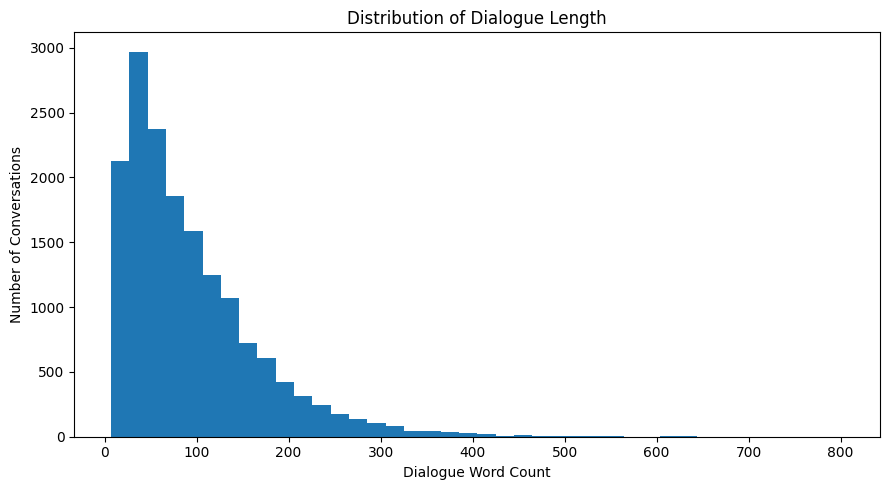

In [10]:
# Dialogue word-count distribution

plt.figure(figsize=(9, 5))
plt.hist(eda_df["dialogue_word_count"], bins=40)
plt.title("Distribution of Dialogue Length")
plt.xlabel("Dialogue Word Count")
plt.ylabel("Number of Conversations")
plt.tight_layout()
plt.show()


### Dialogue Length Interpretation

Dialogue length is strongly right-skewed. Most conversations are relatively
short, with a median length of 73 words, while a small number contain several
hundred words and the longest reaches 803 words.

This long tail is important for model preparation because transformer input
length is limited. Token-length analysis will therefore be used to select a
maximum input length that preserves most conversations while keeping training
computationally practical.

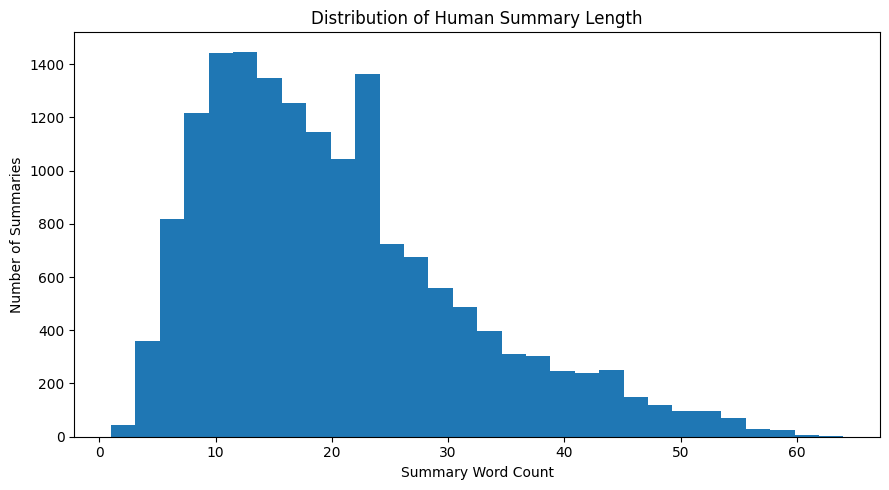

In [11]:
# Human-summary word-count distribution

plt.figure(figsize=(9, 5))
plt.hist(eda_df["summary_word_count"], bins=30)
plt.title("Distribution of Human Summary Length")
plt.xlabel("Summary Word Count")
plt.ylabel("Number of Summaries")
plt.tight_layout()
plt.show()


### Summary Length Interpretation

Human-written summaries are much shorter and more concentrated than the
original dialogues. The median summary contains 18 words, while 95% contain
43 words or fewer.

This supports the use of a relatively short decoder target length during
model preparation. Token-based analysis will be used next to determine an
appropriate maximum summary length without unnecessary padding or truncation.

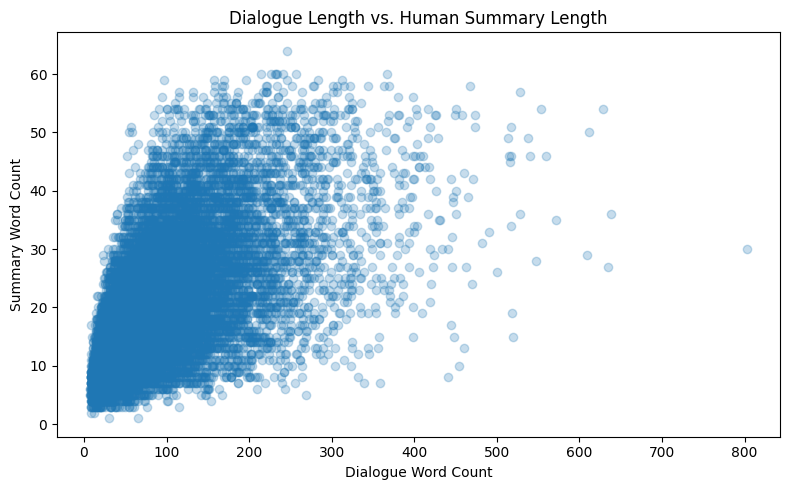

In [12]:
# Dialogue length versus summary length

plt.figure(figsize=(8, 5))
plt.scatter(
    eda_df["dialogue_word_count"],
    eda_df["summary_word_count"],
    alpha=0.25
)
plt.title("Dialogue Length vs. Human Summary Length")
plt.xlabel("Dialogue Word Count")
plt.ylabel("Summary Word Count")
plt.tight_layout()
plt.show()


### Dialogue-to-Summary Length Interpretation

Longer dialogues generally correspond to longer human-written summaries,
although the relationship is not strictly linear. Summary length becomes more
variable as conversations grow, suggesting that dialogue length alone does not
determine how much information must be preserved.

Even for longer conversations, the reference summaries remain relatively
compact. This supports the project's goal of learning meaningful compression
rather than simply shortening dialogue by a fixed proportion.

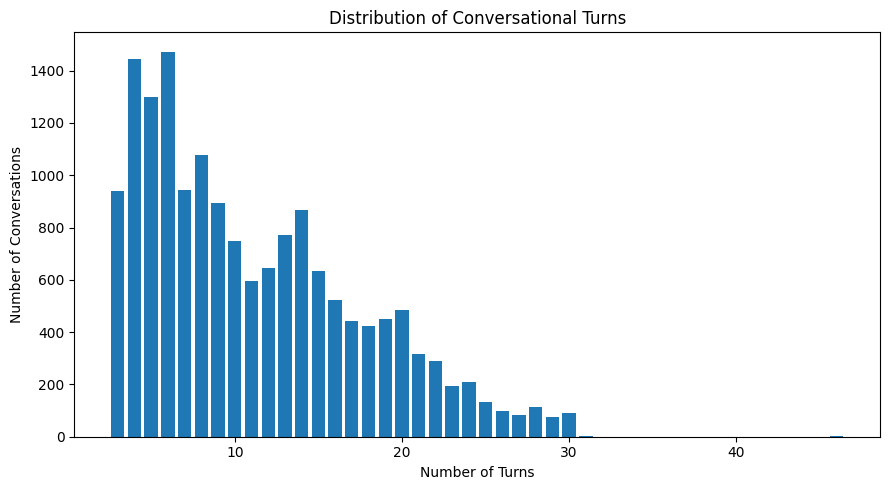

In [13]:
# Distribution of conversational turns

turn_counts = eda_df["turn_count"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(turn_counts.index, turn_counts.values)
plt.title("Distribution of Conversational Turns")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Conversations")
plt.tight_layout()
plt.show()


### Conversational Turn Interpretation

Most conversations contain a moderate number of turns, with a median of
10 and 90% containing 20 turns or fewer. A small number of conversations
extend much further, creating a long tail of more complex dialogue.

Longer multi-turn conversations may be more difficult to summarize because
the model must preserve context across more speaker exchanges. This will be
important during later qualitative evaluation, particularly when reviewing
speaker attribution and omitted information.

# 3. Data Preparation

The next objective is to prepare the dialogue-summary pairs for the planned BERT encoder-decoder architecture.

Because long input sequences increase transformer memory requirements, token lengths will be measured **before** selecting maximum input and target lengths. Speaker labels and conversational wording will be preserved.


In [14]:
# Use the same BERT tokenizer family planned for the encoder-decoder model.

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)
print("Pad token:", tokenizer.pad_token, tokenizer.pad_token_id)
print("CLS token:", tokenizer.cls_token, tokenizer.cls_token_id)
print("SEP token:", tokenizer.sep_token, tokenizer.sep_token_id)
print("Tokenizer model max length:", tokenizer.model_max_length)


Tokenizer: bert-base-uncased
Vocabulary size: 30522
Pad token: [PAD] 0
CLS token: [CLS] 101
SEP token: [SEP] 102
Tokenizer model max length: 512


In [15]:
# Measure token lengths without truncation so the max-length decision is data-driven.

def get_token_lengths(texts, batch_size=512):
    lengths = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )
        lengths.extend(len(ids) for ids in encoded["input_ids"])

    return lengths

all_dialogues = eda_df["dialogue"].fillna("").tolist()
all_summaries = eda_df["summary"].fillna("").tolist()

eda_df["dialogue_token_count"] = get_token_lengths(all_dialogues)
eda_df["summary_token_count"] = get_token_lengths(all_summaries)

token_stats = eda_df[
    ["dialogue_token_count", "summary_token_count"]
].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).T

display(token_stats.round(2))


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (523 > 512). Running this sequence through the model will result in indexing errors


,count,mean,std,min,50%,75%,90%,95%,99%,max
dialogue_token_count,16271.0,137.35,102.65,13.0,109.0,185.0,273.0,339.0,492.0,1095.0
summary_token_count,16271.0,27.23,13.74,3.0,24.0,35.0,47.0,55.0,68.0,86.0


In [16]:
# Show how much of the dataset would be retained at practical token limits.

def coverage_at_limits(series, limits):
    return pd.DataFrame({
        "max_length": limits,
        "coverage_pct": [
            100 * (series <= limit).mean()
            for limit in limits
        ]
    })

input_coverage = coverage_at_limits(
    eda_df["dialogue_token_count"],
    [128, 192, 256, 384, 512]
)

target_coverage = coverage_at_limits(
    eda_df["summary_token_count"],
    [32, 48, 64, 96, 128]
)

print("Dialogue token coverage:")
display(input_coverage.round(2))

print("Summary token coverage:")
display(target_coverage.round(2))


Dialogue token coverage:


,max_length,coverage_pct
0,128,57.25
1,192,76.82
2,256,88.05
3,384,96.98
4,512,99.23


Summary token coverage:


,max_length,coverage_pct
0,32,70.66
1,48,91.13
2,64,98.24
3,96,100.00
4,128,100.00


### Token-Length Decision

Based on the observed token distributions, the maximum input length was set
to **384 tokens**, which preserves approximately **96.98%** of dialogues.
The maximum target length was set to **64 tokens**, which preserves
approximately **98.24%** of human-written summaries.

These values provide strong coverage of the SAMSum dataset while avoiding
the additional computational cost of processing every dialogue at BERT's
512-token maximum.

In [17]:
# Final token-length settings selected from the observed coverage analysis.

MAX_INPUT_LENGTH = 384
MAX_TARGET_LENGTH = 64

print("Maximum dialogue tokens:", MAX_INPUT_LENGTH)
print("Maximum summary tokens:", MAX_TARGET_LENGTH)

print(
    "Dialogue coverage:",
    f"{100 * (eda_df['dialogue_token_count'] <= MAX_INPUT_LENGTH).mean():.2f}%"
)
print(
    "Summary coverage:",
    f"{100 * (eda_df['summary_token_count'] <= MAX_TARGET_LENGTH).mean():.2f}%"
)


Maximum dialogue tokens: 384
Maximum summary tokens: 64
Dialogue coverage: 96.98%
Summary coverage: 98.24%


In [18]:
# Tokenize the cleaned train/validation/test splits.
# Padding is intentionally deferred to batch construction so batches can be
# padded dynamically rather than padding every example to the global maximum.

def preprocess_batch(batch):
    model_inputs = tokenizer(
        batch["dialogue"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=batch["summary"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

columns_to_remove = clean_dataset["train"].column_names

tokenized_dataset = clean_dataset.map(
    preprocess_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing SAMSum"
)

tokenized_dataset


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14638
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 814
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
})

In [19]:
# Inspect one tokenized example before moving to model construction.

sample = tokenized_dataset["train"][0]

print("Input token count:", len(sample["input_ids"]))
print("Label token count:", len(sample["labels"]))

print("\nDecoded dialogue:")
print(tokenizer.decode(sample["input_ids"], skip_special_tokens=True))

print("\nDecoded target summary:")
print(tokenizer.decode(sample["labels"], skip_special_tokens=True))


Input token count: 28
Label token count: 12

Decoded dialogue:
amanda : i baked cookies. do you want some? jerry : sure! amanda : i ' ll bring you tomorrow : - )

Decoded target summary:
amanda baked cookies and will bring jerry some tomorrow.


In [20]:
# Quantify truncation under the selected limits.
# This should be reported transparently in the notebook.

dialogue_truncation_rate = 100 * (
    eda_df["dialogue_token_count"] > MAX_INPUT_LENGTH
).mean()

summary_truncation_rate = 100 * (
    eda_df["summary_token_count"] > MAX_TARGET_LENGTH
).mean()

print(f"Dialogues requiring truncation: {dialogue_truncation_rate:.2f}%")
print(f"Summaries requiring truncation: {summary_truncation_rate:.2f}%")


Dialogues requiring truncation: 3.02%
Summaries requiring truncation: 1.76%


### Data Preparation Summary

The final preprocessing pipeline uses a maximum dialogue length of **384 tokens**
and a maximum summary length of **64 tokens**. Under these settings, only
**3.02% of dialogues** and **1.76% of reference summaries** require truncation.

This provides strong dataset coverage while reducing unnecessary computational
cost during transformer training. The cleaned and tokenized dataset is now ready
for model construction and pilot training.

# 4. Modeling

To keep training practical on CPU, the proof of concept uses a compact pre-trained BERT checkpoint for both the encoder and decoder. This preserves the planned BERT encoder-decoder architecture while reducing training cost compared with BERT-base on both sides.


In [24]:
from transformers import (
    EncoderDecoderModel,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback
)

tokenizer.bos_token = tokenizer.cls_token
tokenizer.eos_token = tokenizer.sep_token

MODEL_CHECKPOINT = "google/bert_uncased_L-4_H-256_A-4"

model = EncoderDecoderModel.from_encoder_decoder_pretrained(
    MODEL_CHECKPOINT,
    MODEL_CHECKPOINT
)

model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.eos_token_id = tokenizer.sep_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

model.generation_config.decoder_start_token_id = tokenizer.cls_token_id
model.generation_config.eos_token_id = tokenizer.sep_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.max_length = MAX_TARGET_LENGTH
model.generation_config.num_beams = 2
model.generation_config.no_repeat_ngram_size = 3

n_params = sum(p.numel() for p in model.parameters())

print("Model checkpoint:", MODEL_CHECKPOINT)
print(f"Total parameters: {n_params:,}")
print("Device available:", "GPU" if torch.cuda.is_available() else "CPU")


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] BertLMHeadModel LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                                                    | Status     | 
-----------------------------------------------------------------------+------------+-
cls.seq_relationship.bias                                              | UNEXPECTED | 
bert.pooler.dense.weight                                               | UNEXPECTED | 
bert.pooler.dense.bias                                                 | UNEXPECTED | 
cls.seq_relationship.weight                                            | UNEXPECTED | 
bert.encoder.layer.{0, 1, 2, 3}.crossattention.self.key.weight         | MISSING    | 
bert.encoder.layer.{0, 1, 2, 3}.crossattention.output.LayerNorm.weight | MISSING    | 
bert.encoder.layer.{0, 1, 2, 3}.crossattention.self.value.bias         | MISSING    | 
bert.encoder.layer.{0, 1, 2, 3}.crossattention.output.dense.bias       | MISSING    | 
bert.encoder.layer.{0, 1, 2, 3}.crossattention.

Model checkpoint: google/bert_uncased_L-4_H-256_A-4
Total parameters: 23,426,874
Device available: CPU


### MVP Training Scope

The local environment is CPU-only, so the MVP uses a controlled subset rather than an unnecessarily expensive full-dataset run. The same pipeline can later be expanded if GPU resources are available.


In [22]:
SEED = 42

TRAIN_SIZE = min(3000, len(tokenized_dataset["train"]))
VAL_SIZE = min(300, len(tokenized_dataset["validation"]))
TEST_SIZE = min(300, len(tokenized_dataset["test"]))

train_mvp = tokenized_dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
val_mvp = tokenized_dataset["validation"].shuffle(seed=SEED).select(range(VAL_SIZE))
test_mvp = tokenized_dataset["test"].shuffle(seed=SEED).select(range(TEST_SIZE))

print(f"MVP train examples:      {len(train_mvp):,}")
print(f"MVP validation examples: {len(val_mvp):,}")
print(f"MVP test examples:       {len(test_mvp):,}")


MVP train examples:      3,000
MVP validation examples: 300
MVP test examples:       300


# 5. Training and Optimization

Training uses a small batch size, gradient accumulation, validation after each epoch, and checkpointing. The objective is a reliable proof of concept rather than an exhaustive hyperparameter search.


In [25]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100
)

training_args = Seq2SeqTrainingArguments(
    output_dir="./gridiron_brief_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    weight_decay=0.01,
    num_train_epochs=2,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=2,
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
    dataloader_pin_memory=False
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_mvp,
    eval_dataset=val_mvp,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

trainer.train()


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 101}.


Epoch,Training Loss,Validation Loss
1,19.117424,4.468257
2,17.415159,4.343358


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.cls.predictions.decoder.weight', 'decoder.cls.predictions.decoder.bias'].


TrainOutput(global_step=376, training_loss=19.24746160304293, metrics={'train_runtime': 1255.1967, 'train_samples_per_second': 4.78, 'train_steps_per_second': 0.3, 'total_flos': 63959251009488.0, 'train_loss': 19.24746160304293, 'epoch': 2.0})

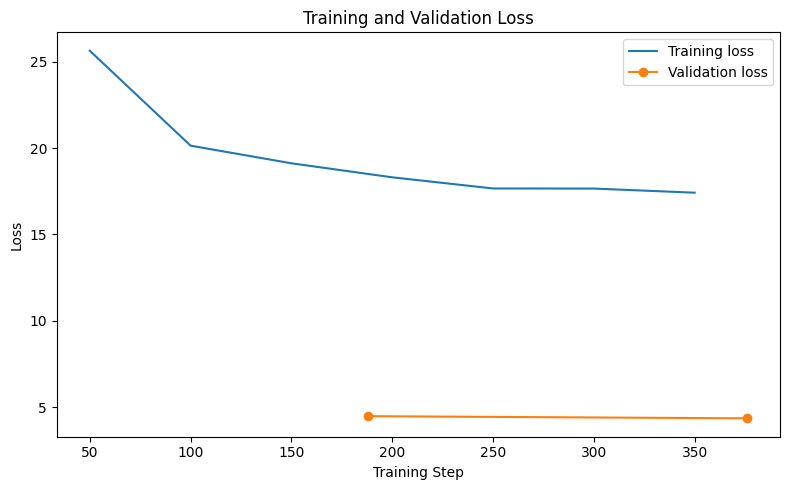

In [26]:
# Plot training and validation loss.

history = pd.DataFrame(trainer.state.log_history)

train_history = history.dropna(subset=["loss"])
eval_history = history.dropna(subset=["eval_loss"])

plt.figure(figsize=(8, 5))

if not train_history.empty:
    plt.plot(train_history["step"], train_history["loss"], label="Training loss")

if not eval_history.empty:
    plt.plot(eval_history["step"], eval_history["eval_loss"], marker="o", label="Validation loss")

plt.title("Training and Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


# 6. Evaluation

ROUGE-1, ROUGE-2, and ROUGE-L are calculated on the held-out MVP test subset. These scores are supplemented with direct inspection of generated summaries.


In [27]:
from rouge_score import rouge_scorer, scoring

prediction_output = trainer.predict(test_mvp)

pred_ids = prediction_output.predictions
label_ids = prediction_output.label_ids

if isinstance(pred_ids, tuple):
    pred_ids = pred_ids[0]

label_ids = np.where(
    label_ids != -100,
    label_ids,
    tokenizer.pad_token_id
)

generated_summaries = tokenizer.batch_decode(
    pred_ids,
    skip_special_tokens=True
)

reference_summaries = tokenizer.batch_decode(
    label_ids,
    skip_special_tokens=True
)

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

aggregator = scoring.BootstrapAggregator()

for reference, generated in zip(reference_summaries, generated_summaries):
    aggregator.add_scores(scorer.score(reference, generated))

rouge = aggregator.aggregate()

rouge_results = {
    "ROUGE-1": rouge["rouge1"].mid.fmeasure * 100,
    "ROUGE-2": rouge["rouge2"].mid.fmeasure * 100,
    "ROUGE-L": rouge["rougeL"].mid.fmeasure * 100
}

results_df = pd.DataFrame({
    "Metric": rouge_results.keys(),
    "Score": rouge_results.values()
})

display(results_df.round(2))


,Metric,Score
0,ROUGE-1,13.99
1,ROUGE-2,2.13
2,ROUGE-L,12.16


In [28]:
# Compare MVP results with the targets stated in the pitch.

targets = {
    "ROUGE-1": 35,
    "ROUGE-2": 12,
    "ROUGE-L": 32
}

comparison_df = pd.DataFrame({
    "Metric": targets.keys(),
    "Pitch Target": targets.values(),
    "MVP Result": [rouge_results[m] for m in targets]
})

comparison_df["Target Met"] = (
    comparison_df["MVP Result"] >= comparison_df["Pitch Target"]
)

display(comparison_df.round(2))


,Metric,Pitch Target,MVP Result,Target Met
0,ROUGE-1,35,13.99,False
1,ROUGE-2,12,2.13,False
2,ROUGE-L,32,12.16,False


# 7. Qualitative Error Analysis

A small sample is reviewed alongside the human reference to identify strengths and common failure modes such as omitted details, speaker confusion, repetition, or hallucination.


In [29]:
raw_test_mvp = clean_dataset["test"].shuffle(seed=SEED).select(range(TEST_SIZE))

sample_rows = []

for i in range(min(8, TEST_SIZE)):
    sample_rows.append({
        "Dialogue": raw_test_mvp[i]["dialogue"],
        "Reference Summary": reference_summaries[i],
        "Generated Summary": generated_summaries[i]
    })

sample_outputs_df = pd.DataFrame(sample_rows)
display(sample_outputs_df)


,Dialogue,Reference Summary,Generated Summary
0,Claire: <file_photo>\nKim: Looks delicious...\...,both claire and linda are making curry for din...,tina is going to meet at the hotel.
1,Alyssa: Have you seen Fergie’s national anthem...,derek and alyssa make fun of fergie ' s perfor...,kate is going to meet with kate. kate will go ...
2,"Ann: Hi, is the laptop still available?\nJosh:...",ann wants to buy josh ' s laptop for $ 200. jo...,tom is going to buy a photo for a photo of the...
3,Matt: have you heard that Bon Jovi are coming ...,matt and tony want to go to the concert of bon...,mike is going to meet at the hotel.
4,Anastasia: Our new school photos\nAnastasia: <...,anastasia sent her new school photos to darrell.,kate is going to meet with kate ' s girlfriend...
5,Mike: who is going for the research trip?\nJak...,"jake, florence, margot and others are going on...",tom is going to meet at the hotel. tom will be...
6,Nathalie: have you thought about the holiday?\...,"nathalie, pauline, jacob and anthony are think...",anna is going to meet with anna. anna will go ...
7,"Kim: Hey, listen, have you got any idea where ...",kim needs to get some fresh fish in warsaw. ki...,tom is going to meet at the hotel. tom will go...


### Error-Analysis Notes

Qualitative review revealed a clear hallucination pattern in the MVP model. Although the reference summaries accurately captured the central events in each dialogue, the generated summaries frequently introduced unsupported names, locations, and actions. Several unrelated conversations produced similar phrases such as meeting at a hotel, suggesting that the model learned repetitive high-frequency generation patterns rather than consistently grounding its output in the source dialogue.

The model therefore demonstrates that the end-to-end summarization pipeline is functional, but its current factual reliability is not sufficient for deployment. This is consistent with the low ROUGE scores and likely reflects the intentionally limited MVP training setup: a compact BERT encoder-decoder, 3,000 training examples, two epochs, and CPU-constrained training.

# 8. Fantasy Football Demonstration

These examples test domain transfer to fantasy-football-style conversations. SAMSum remains the formal evaluation dataset.


In [30]:
fantasy_dialogues = [
    """Mike: I’ll send you DeVonta Smith and James Cook for your Amon-Ra.
Jordan: Too much risk for me at receiver.
Mike: What if I add my second waiver priority?
Jordan: Still no. I’m keeping Amon-Ra.
Chris: Trade deadline is tomorrow night, by the way.""",

    """Alex: My starting running back was ruled out Sunday.
Ben: Are you starting his backup?
Alex: Probably, unless I get Ford off waivers.
Sam: Waivers process tonight.
Alex: Then I’ll put in the claim now.""",

    """Commissioner: Vote is open on changing playoffs from four teams to six.
Ryan: I vote six.
Chris: Four.
Matt: Six.
Jordan: Six.
Commissioner: Six teams wins. I’ll update the settings tonight.""",

    """Ben: Who has first waiver priority?
Chris: You do.
Ben: I’m putting in for the rookie receiver.
Chris: I want the tight end who had two touchdowns.
Mike: Claims process at 3 AM.""",

    """Jordan: Crazy game last night.
Mike: My defense saved me.
Chris: Anyone see the injury report?
Jordan: Yeah, my receiver is questionable.
Mike: I sent you a trade offer.
Jordan: I saw it. I’ll decide after practice reports tomorrow."""
]

def generate_summary(dialogue):
    inputs = tokenizer(
        dialogue,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=MAX_TARGET_LENGTH,
            num_beams=2,
            no_repeat_ngram_size=3
        )

    return tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

fantasy_results = pd.DataFrame({
    "Scenario": [
        "Trade Negotiation",
        "Injury and Waivers",
        "League Vote",
        "Waiver Wire",
        "Mixed League Chat"
    ],
    "Generated Gridiron Brief": [
        generate_summary(dialogue)
        for dialogue in fantasy_dialogues
    ]
})

display(fantasy_results)


,Scenario,Generated Gridiron Brief
0,Trade Negotiation,john is going to meet at the hotel.
1,Injury and Waivers,tom is going to meet at the airport.
2,League Vote,mike is going to meet at 5 pm pm.
3,Waiver Wire,tom is going to meet at the airport.
4,Mixed League Chat,tom is going to meet at the gym.


# 9. Deployment Considerations and Conclusions

The Gridiron Brief MVP successfully demonstrates an end-to-end dialogue summarization pipeline using a BERT-based encoder-decoder architecture. The system loads and prepares conversational data, trains a transformer model, generates summaries, and evaluates performance using both quantitative and qualitative methods.

The current MVP did not meet the original ROUGE targets. Test performance reached **ROUGE-1 = 13.99**, **ROUGE-2 = 2.13**, and **ROUGE-L = 12.16**. Qualitative evaluation also revealed a major factual-reliability problem: the model frequently generated unsupported names, locations, and actions and repeated similar generic phrases across unrelated conversations.

The fantasy football demonstration confirmed that this limitation also affects the intended Gridiron Brief use case. Rather than accurately summarizing trades, waiver activity, injuries, and league decisions, the model frequently produced unrelated statements such as users meeting at hotels, airports, or other locations. Therefore, the current model should be considered a functional proof of concept rather than a deployment-ready summarization system.

The results are consistent with the deliberately constrained MVP setup, which used a compact BERT encoder-decoder, 3,000 training examples, two epochs, and CPU-only training. Future development should test additional training data and epochs, GPU-based training, stronger generation settings, and fantasy-football-specific fine-tuning. Any deployed version should also include safeguards for hallucination, privacy protections for league chat data, and continued access to the original conversation so users can verify generated summaries.